In [2]:
import pandas as pd #readíng dataset
import numpy as np #data operations
import matplotlib.pyplot as plt # plotting graphs
import seaborn as sns #data visualization
from sklearn.model_selection import train_test_split # splits dataset into train and test
from sklearn.preprocessing import StandardScaler, OneHotEncoder #categorical to numerical conversion
from sklearn.compose import ColumnTransformer # apply different preprocessing to columns
from sklearn.pipeline import Pipeline # create full ML pipeline
from sklearn.linear_model import LogisticRegression # linear classification model
from sklearn.ensemble import RandomForestClassifier # tree-based ensemble model
from sklearn.neural_network import MLPClassifier # neural network model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score # evaluation metrics
from sklearn.model_selection import GridSearchCV # hyperparameter tuning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv("bank-full.csv", sep=';')
df.head()
#reads the data and shows the first five lines for control

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
#data cleaning

df = df.replace("unknown", np.nan)
#convert unknown values to NaN 

print(df.isnull().sum())
#check how many missing values exist in each column

#fill missing values 
numerical_cols = df.select_dtypes(include=[np.number]).columns #balance, age, duration
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include=['object']).columns #job, education, martial
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])    


age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64


In [5]:
X = df.drop("y", axis=1)
#features (independent variables)
y = df["y"].map({"yes": 1, "no": 0})
#target variable → convert yes/no to 1/0

In [6]:
#preprocessing

cat_cols = X.select_dtypes(include=["object"]).columns
#categorical columns (string)
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
#numerical columns

In [7]:
numeric_transformer = MinMaxScaler()
#normalize numerical features
categorical_transformer = OneHotEncoder(handle_unknown="ignore")
#convert categorical variables into numeric

#organization
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols), #apply scaling to numeric columns
        ("cat", categorical_transformer, cat_cols) #apply encoding to categorical columns
    ]
)

In [8]:
#traín/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#80% train, 20% test, stratify ensures class distribution remains balanced

In [9]:
#3 diffferent model
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Neural Network": MLPClassifier(max_iter=500)
}

results = []

for name, model in models.items():
    pipe = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train) #train the model
    y_pred = pipe.predict(X_test)  #make predictions on test data
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1
    })
    
    print(f"\n{'='*30}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"{'-'*30}")
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results)
print("\n" + "="*20 + " COMPARISON " + "="*20)
print(results_df.sort_values(by="F1-Score", ascending=False).to_string(index=False))


Model: Logistic Regression
Accuracy: 0.8437
F1-Score: 0.5381
------------------------------
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.41      0.78      0.54      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.82      0.72      9043
weighted avg       0.90      0.84      0.86      9043


Model: Random Forest
Accuracy: 0.8931
F1-Score: 0.5708
------------------------------
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7985
           1       0.54      0.61      0.57      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.77      0.75      9043
weighted avg       0.90      0.89      0.90      9043


Model: Neural Network
Accuracy: 0.8619
F1-Score: 0.5313
------------------------------
              precision    recall  f1-score   support

           0       0.95

In [10]:
#hyperparameter tuning

pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier())
]) #choosing the best model

param_grid = {
    "model__n_estimators": [100, 200], #number of trees
    "model__max_depth": [5, 10, None] #depth of trees
} 

grid = GridSearchCV(pipe, param_grid, cv=3, scoring="accuracy") #trying all combinations and find the best one
#cross-validation; 2 train 1 test
grid.fit(X_train, y_train) #train models with different parameter combinations

print("Best Params:", grid.best_params_)
best_model = grid.best_estimator_

Best Params: {'model__max_depth': None, 'model__n_estimators': 100}


Final Accuracy: 0.8943934534999447
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7985
           1       0.54      0.61      0.58      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.77      0.76      9043
weighted avg       0.90      0.89      0.90      9043



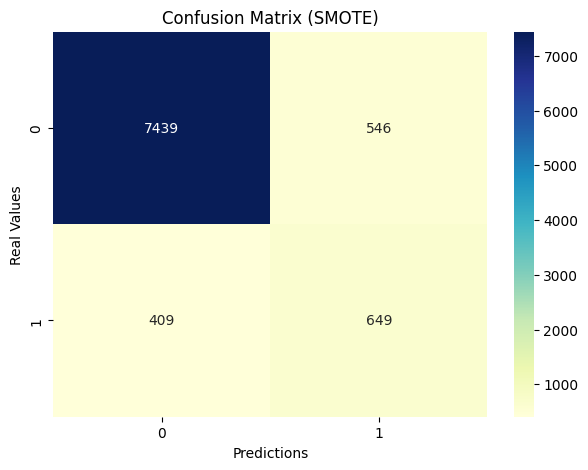

In [11]:
y_pred = best_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix (SMOTE)")
plt.ylabel('Real Values')
plt.xlabel('Predictions')
plt.show()

In [ ]:
import joblib

joblib.dump({
    "model": best_model,
    "columns": X.columns
}, "model_bundle.pkl")

['model.pkl']